In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# %matplotlib notebook
%matplotlib inline


# Few command to make the plot nicer 
# (use latex for typesetting and bigger fonts)
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14) 


In [2]:
#set this directory to where the files you want to analyze are
dir = "./data/"
#dir = "./"

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

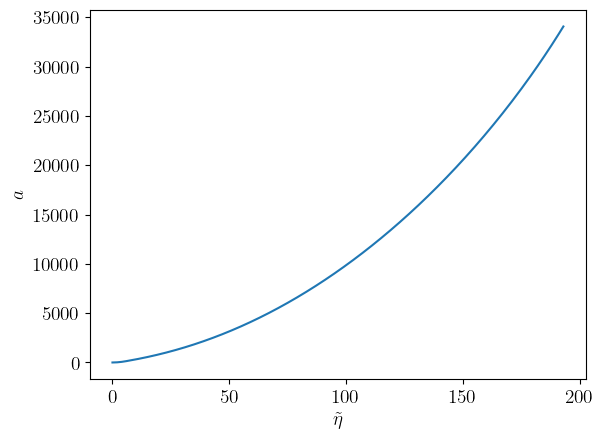

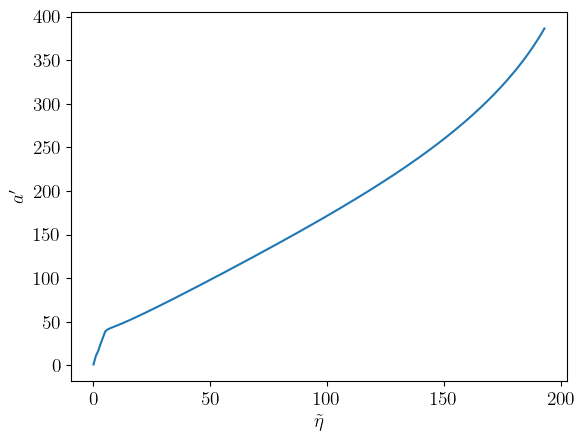

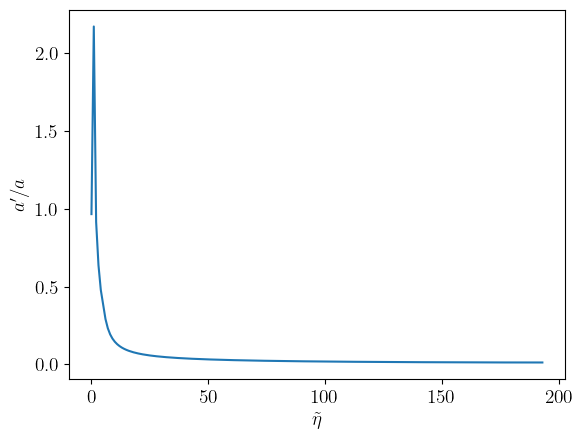

In [3]:
expansion = True

if expansion == True:
    # load the file in aDat
    aDat = np.loadtxt(dir + "average_scale_factor.txt")
    
    #plot a
    plt.figure(0)
    plt.plot(aDat[:,0], aDat[:,1])
    plt.ylabel(r"$a$")
    plt.xlabel(r'$\tilde \eta$')
    
    #plot a'
    plt.figure(1)
    plt.plot(aDat[:,0], aDat[:,2])
    plt.ylabel(r"$a'$")
    plt.xlabel(r'$\tilde \eta$')
    
    
    #plot a'/a
    plt.figure(2)
    plt.plot(aDat[:,0], aDat[:,3])
    plt.ylabel(r"$a'/a$")
    plt.xlabel(r"$\tilde \eta$");

else:
    aDat = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [4]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.figure(0)
    plt.plot(fldDat[:,0], fldDat[:,1], "-o")
    plt.xlabel(r"$\tilde \eta$")
    plt.ylabel(r"$\langle \phi_"+ fldNum +r"\rangle$")
    
    if aDat is not None:
        plt.figure(1)
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1], "-o")
        plt.xlabel(r"$\tilde \eta$")
        plt.ylabel(r"$a \cdot \langle \phi_"+ fldNum +r" \rangle$")
    
        plt.figure(2)
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,5], "-o")
        plt.xlabel(r"$\tilde \eta$")
        plt.ylabel(r"$a \cdot rms (\phi_"+ fldNum +")$")
        plt.yscale('log')



## Field $0$ (inflaton)

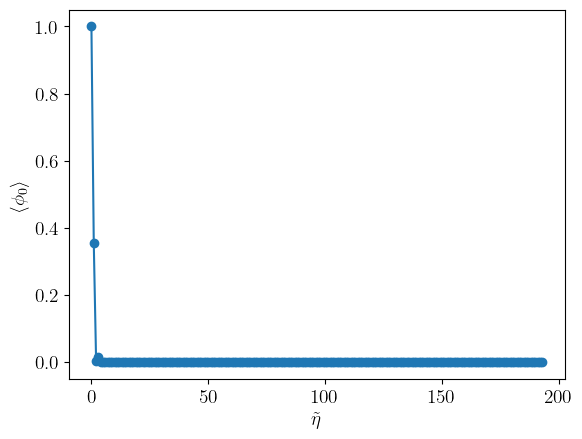

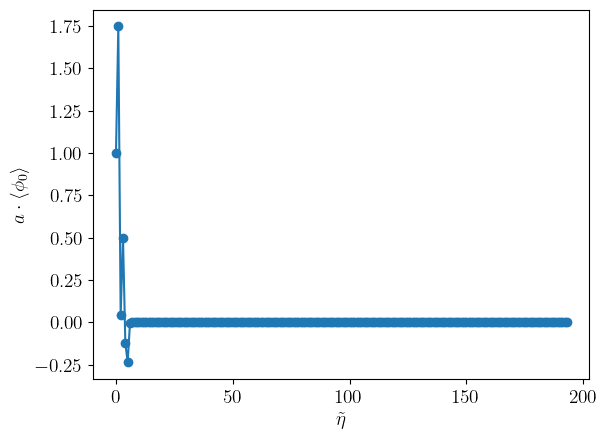

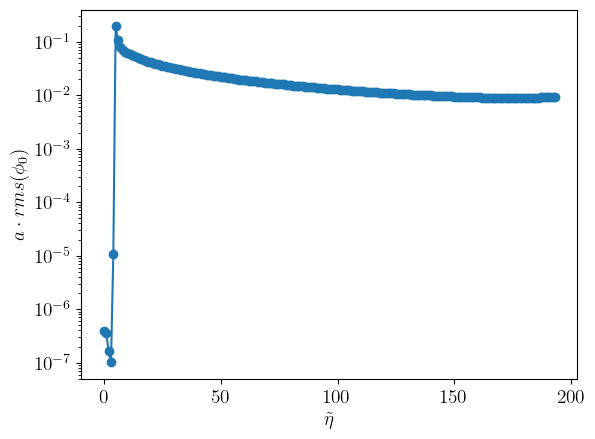

In [5]:
infDat = np.loadtxt(dir + "average_scalar_0.txt")
plot_fld(infDat,"0",aDat)

## Field $1$ (daughter field)

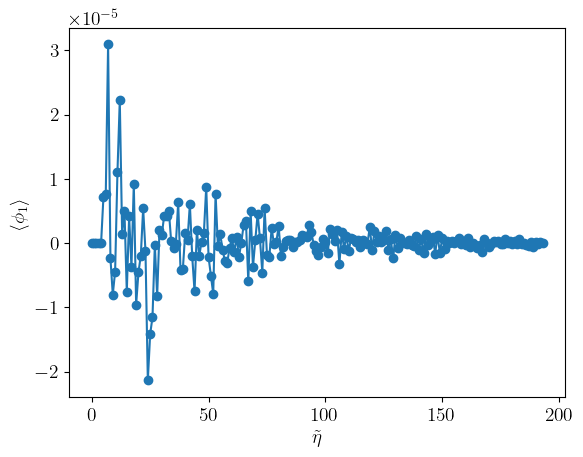

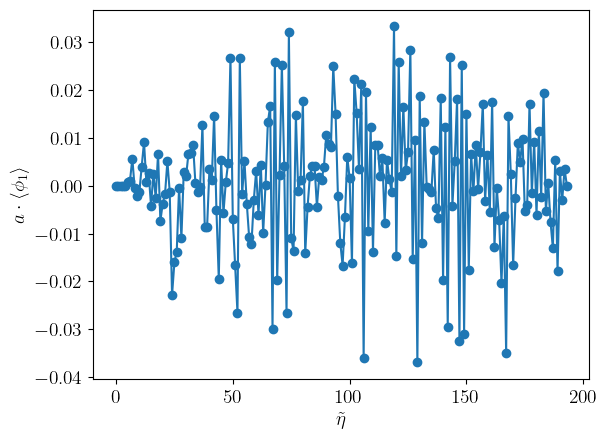

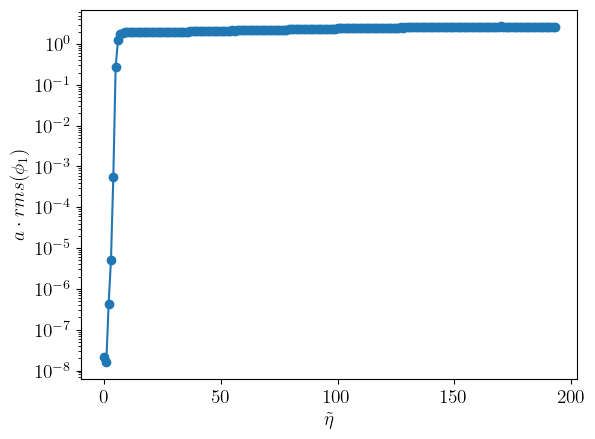

In [6]:
dauDat = np.loadtxt(dir + "average_scalar_1.txt")
plot_fld(dauDat, "1",aDat)

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

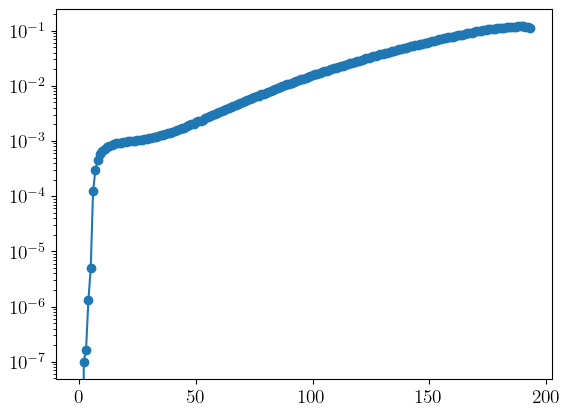

In [13]:
enConsDat = np.loadtxt(dir + "average_energy_conservation.txt")
plt.plot(enConsDat[:,0], enConsDat[:,1], "-o")
plt.yscale('log')
#plt.ylim([1e-8,0.01]);

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

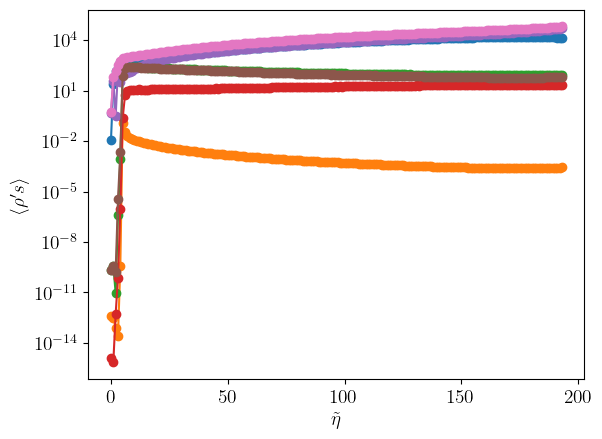

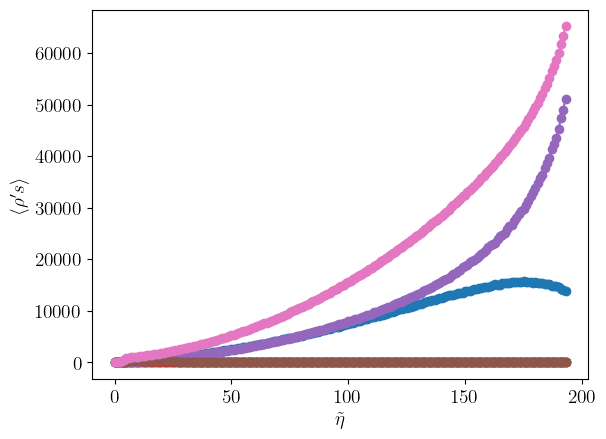

In [15]:
enDat = np.loadtxt(dir + "average_energies.txt")

nColumns = np.shape(enDat)[1]

# set explicitly different colors, so we know who is who
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

if expansion == True:
    plt.figure(0)
    for i in range(1,nColumns):
        plt.plot(enDat[:,0], aDat[:,1]**4 * enDat[:,i], "-o", color = colors[i-1])
        plt.yscale('log')
        plt.xlabel(r"$\tilde \eta$")
        plt.ylabel(r"$\langle \rho's \rangle$")
        
    plt.figure(1)
    for i in range(1,nColumns):
        plt.plot(enDat[:,0], aDat[:,1]**4 * enDat[:,i], "-o", color = colors[i-1])
        plt.xlabel(r"$\tilde \eta$")
        plt.ylabel(r"$\langle \rho's \rangle$")
else:
    plt.figure(0)
    for i in range(1,nColumns):
        plt.plot(enDat[:,0], enDat[:,i], "-o", color = colors[i-1])
        plt.yscale('log')
        plt.xlabel(r"$\tilde \eta$")
        plt.ylabel(r"$\langle \rho's \rangle$")
        
    plt.figure(1)
    for i in range(1,nColumns):
        plt.plot(enDat[:,0], enDat[:,i], "-o", color = colors[i-1])
        plt.xlabel(r"$\tilde \eta$")
        plt.ylabel(r"$\langle \rho's \rangle$")
    

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [9]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap = 'plasma'):
    colors = plt.get_cmap(colormap)
    for i in range(nSpectra):
        plt.plot(spectra[i*nBins:(i+1)*nBins,0], np.abs(spectra[i*nBins:(i+1)*nBins,column]), color=colors(i/nSpectra))
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$\tilde k$')

## Inflaton

Text(0, 0.5, '$\\tilde n_{\\tilde \\phi_0}$')

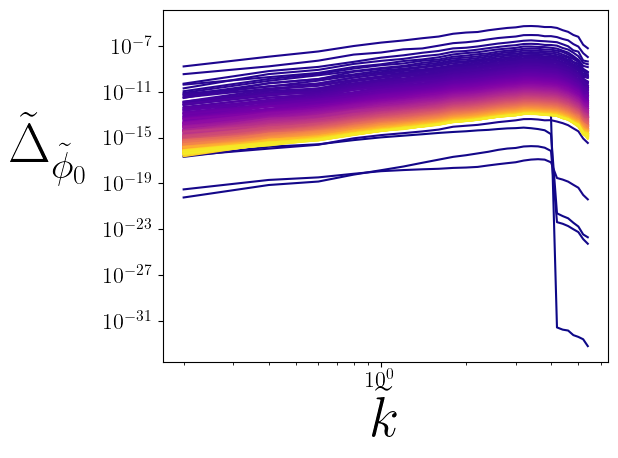

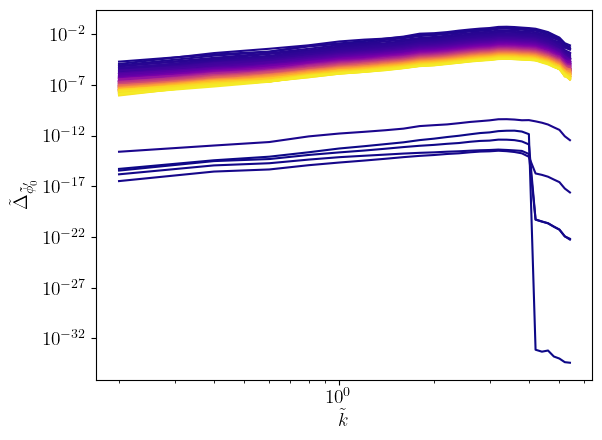

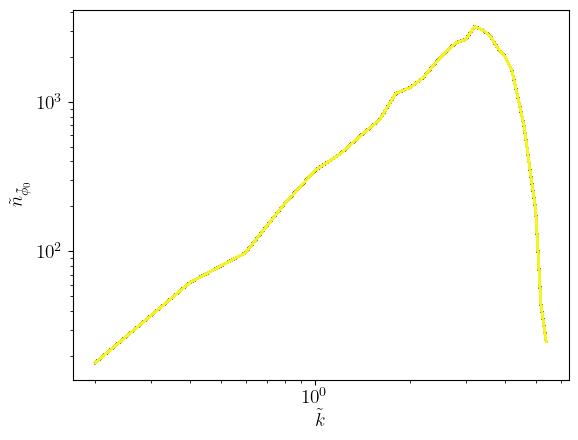

In [20]:
infSp, nBins, nSpectra = load_spectrum(dir + "spectra_scalar_0.txt")

plt.figure(0)
plot_spectrum(infSp, 1,  nBins, nSpectra)
plt.ylabel(r'$\tilde\Delta_{\tilde \phi_0}$', fontsize=40, rotation = 'horizontal', labelpad=40)
plt.xlabel(r'$\tilde k$', fontsize=40)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("cosmolattice_1", format = "pdf")
# plt.ylim([1e-19,1e-4])

plt.figure(1)
plot_spectrum(infSp, 2,  nBins, nSpectra)
plt.ylabel(r"$\tilde\Delta_{\tilde \phi_0'}$")
# plt.ylim([1e-19,1e-4])

plt.figure(2)
plot_spectrum(infSp, 3,  nBins, nSpectra)
plt.ylabel(r'$\tilde n_{\tilde \phi_0}$')
# plt.ylim([1e-1,1e13]);

## Daughter field

Text(0, 0.5, '$\\tilde n_{\\tilde \\phi_1}$')

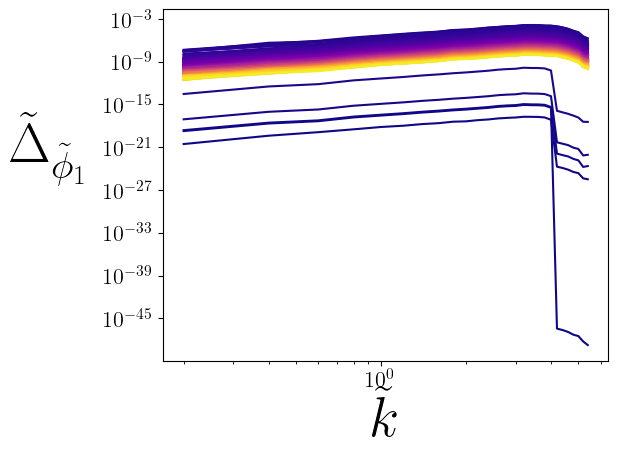

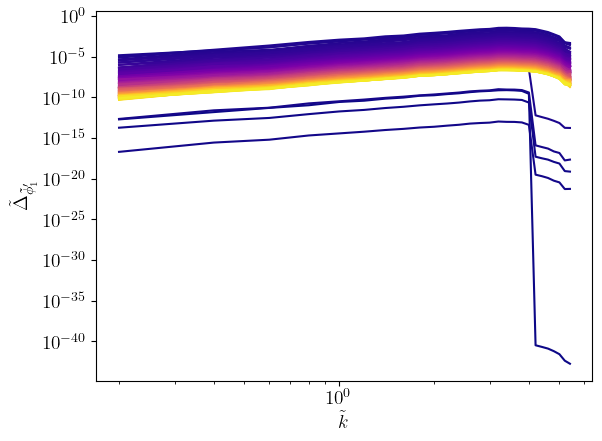

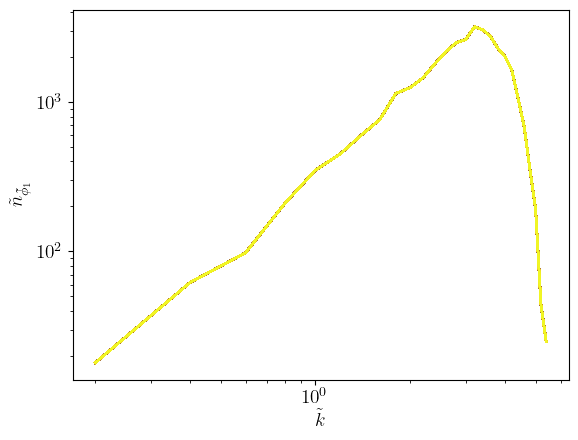

In [21]:
infSp, nBins, nSpectra = load_spectrum(dir + "spectra_scalar_1.txt")

plt.figure(0)
plot_spectrum(infSp, 1,  nBins, nSpectra)
plt.ylabel(r'$\tilde\Delta_{\tilde \phi_1}$', fontsize=40, rotation = 'horizontal', labelpad=40)
plt.xlabel(r'$\tilde k$', fontsize=40)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("cosmolattice_2", format = "pdf")
# plt.ylim([1e-19,1e-4])

plt.figure(1)
plot_spectrum(infSp, 2,  nBins, nSpectra)
plt.ylabel(r"$\tilde\Delta_{\tilde \phi_1'}$")
# plt.ylim([1e-19,1e-4])

plt.figure(2)
plot_spectrum(infSp, 3,  nBins, nSpectra)
plt.ylabel(r'$\tilde n_{\tilde \phi_1}$')
# plt.ylim([1e-1,3e12]);

### GW

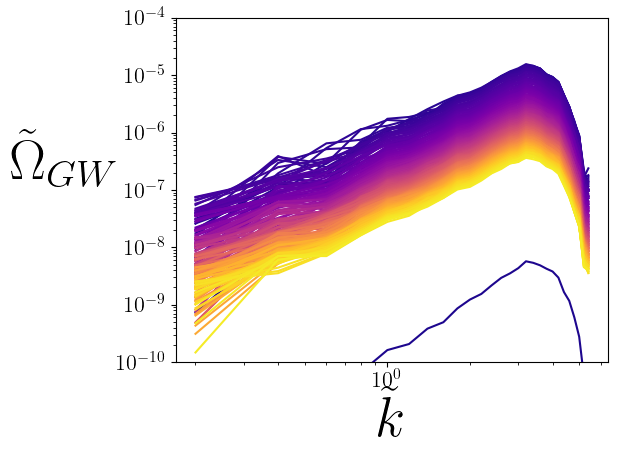

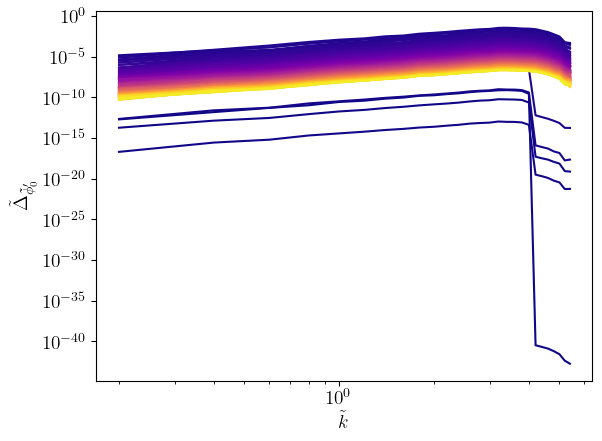

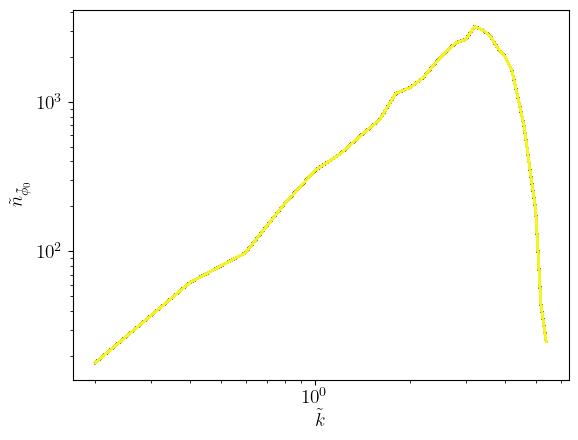

In [25]:
gwSp, nBins, nSpectra = load_spectrum(dir + "spectra_gws.txt")

plt.figure(0)
plot_spectrum(gwSp, 1,  nBins, nSpectra)
plt.ylabel(r'$\tilde\Omega_{GW}$', fontsize=40, rotation = 'horizontal', labelpad=40);
plt.ylim([1e-10,1e-4])
plt.xlabel(r'$\tilde k$', fontsize=40)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("cosmolattice_GW", format = "pdf")

plt.figure(1)
plot_spectrum(infSp, 2,  nBins, nSpectra)
plt.ylabel(r"$\tilde\Delta_{\tilde \phi_0'}$")
# plt.ylim([1e-19,1e-4])

plt.figure(2)
plot_spectrum(infSp, 3,  nBins, nSpectra)
plt.ylabel(r'$\tilde n_{\tilde\phi_0}$');
# plt.ylim([1e-1,1e13]);